In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset
df = pd.read_csv("i40 (datos).csv")

# Definimos las columnas numéricas con sus nombres reales (incluyendo unidades)
cols = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

In [15]:
# Visualizar los primeros registros del dataframa
df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,L,303.80,313.30,1406,52.10,166,normal
1,1,3908,L,302.30,311.20,1633,36.40,114,normal
2,2,10767,M,302.27,311.47,1228,68.75,187,failure
3,3,15484,L,302.35,311.93,1522,36.99,214,failure
4,4,784,L,296.70,307.90,1743,27.90,55,normal


In [16]:
# Vemos información sobre el dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  str    
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  str    
dtypes: float64(3), int64(4), str(2)
memory usage: 1021.1 KB


In [17]:
# Consultamos forma del Datasheet
df.shape

(14521, 9)

In [18]:
print("Resumen estadístico:")
df[cols].describe().T

Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
air_temp [K],14481.0,300.478975,1.952737,295.3,298.90,300.60,302.20,304.5
process_temp [K],14521.0,310.165287,1.329586,305.7,309.20,310.32,311.09,313.8
speed [RPM],14521.0,1513.389436,313.604170,-1.0,1354.00,1423.00,1561.00,2886.0
torque [Nm],14521.0,44.955809,14.226641,3.8,35.99,46.70,55.00,76.6
tool_wear [min],14521.0,124.921700,70.105992,0.0,64.00,127.00,193.00,253.0


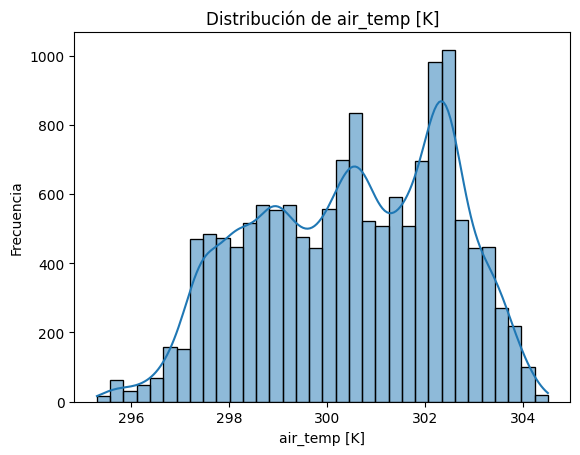

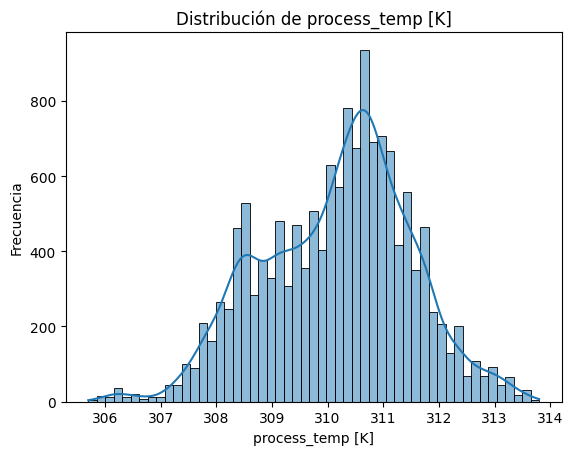

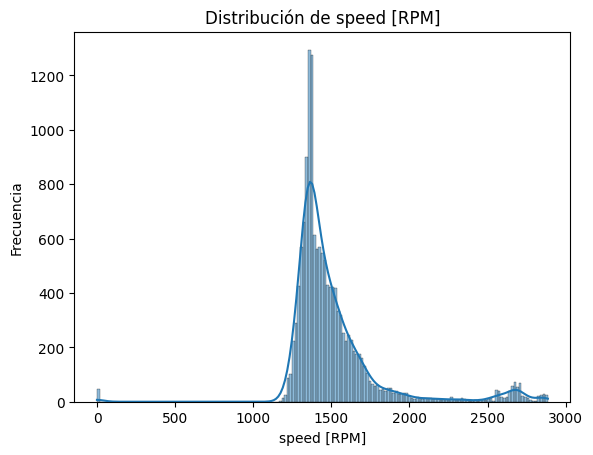

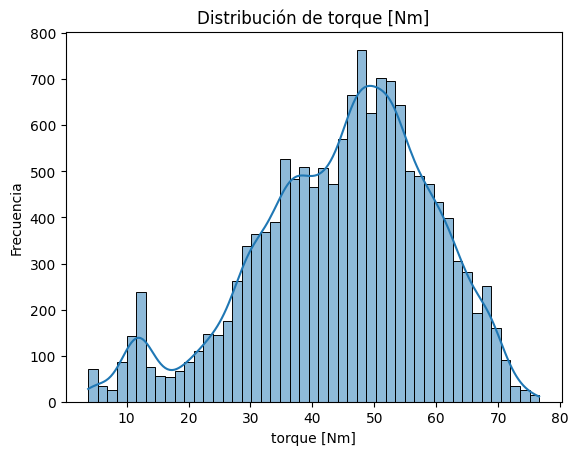

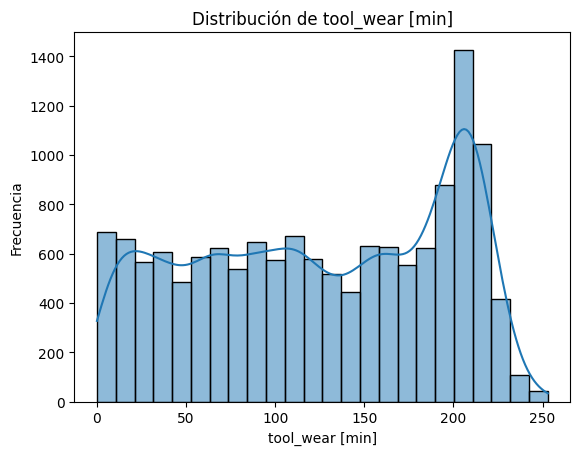

In [19]:
# Distribución de var 
for col in cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

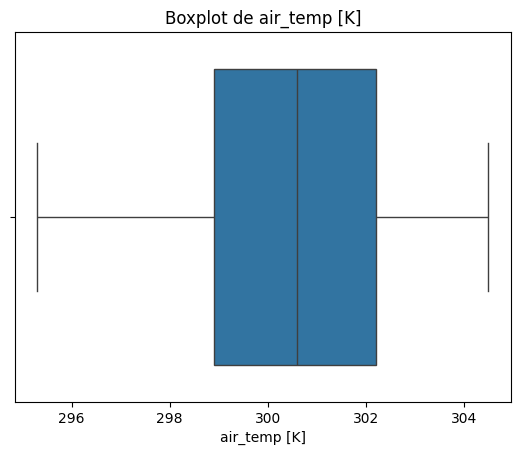

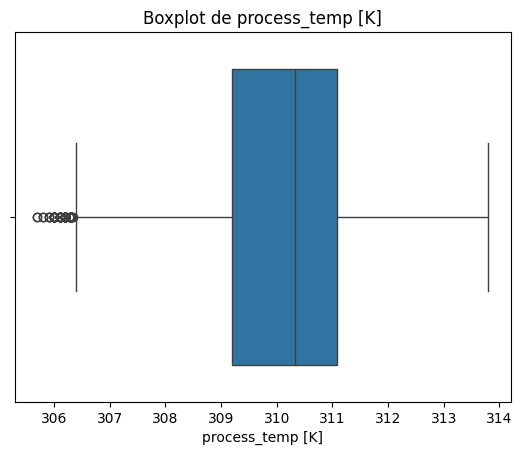

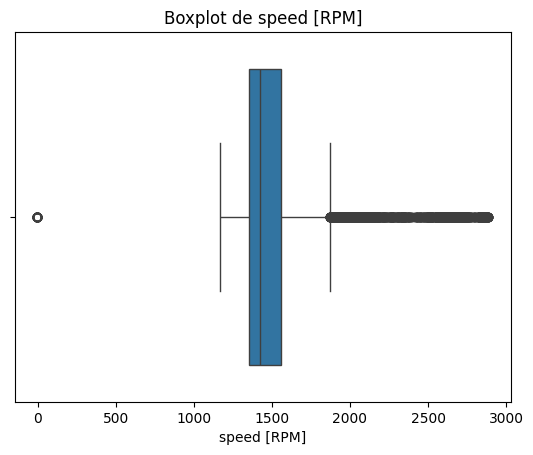

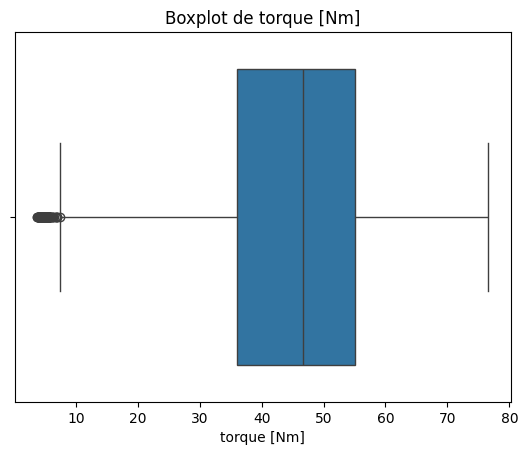

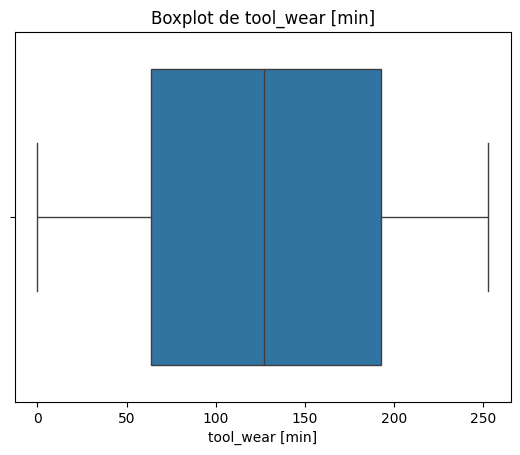

In [20]:
# Medidas de dispersión 
# Boxplots. Muestra la distribución de los datos, identificando mediana, cuartiles y valores extremos (ver presentación de la catedra)
for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [21]:
# Proporciones
# Var objetivo, cuenta los casos 
df['target'].value_counts()

target
failure    7482
normal     7039
Name: count, dtype: int64

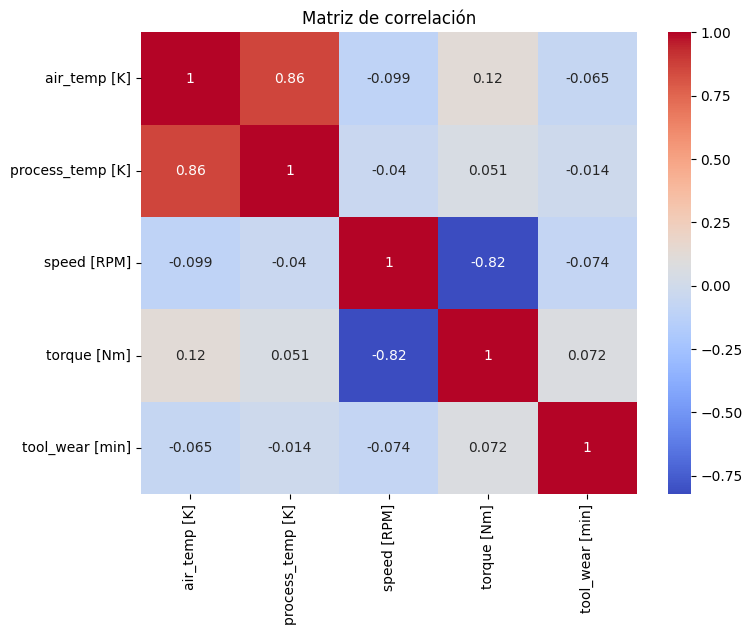

In [22]:
# Correlación entre var 
corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

In [23]:
# Relación entre var
sns.scatterplot(x='torque', y='tool_wear', hue='target', data=df)
plt.title("Torque vs Tool Wear")
plt.show()

ValueError: Could not interpret value `torque` for `x`. An entry with this name does not appear in `data`.

In [ ]:
# Relación entre var 
sns.scatterplot(x='speed', y='torque', hue='target', data=df)
plt.title("Speed vs Torque")
plt.show()

In [ ]:
# Analisis de variables
import pandas as pd
df = pd.read_csv("i40 (datos).csv")
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 14521 entries, 0 to 14520
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   idx               14521 non-null  int64  
 1   parent_device_id  14521 non-null  int64  
 2   product_type      14521 non-null  str    
 3   air_temp [K]      14481 non-null  float64
 4   process_temp [K]  14521 non-null  float64
 5   speed [RPM]       14521 non-null  int64  
 6   torque [Nm]       14521 non-null  float64
 7   tool_wear [min]   14521 non-null  int64  
 8   target            14521 non-null  str    
dtypes: float64(3), int64(4), str(2)
memory usage: 1021.1 KB


,idx,parent_device_id,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min]
count,14521.000000,14521.000000,14481.000000,14521.000000,14521.000000,14521.000000,14521.000000
mean,7260.000000,9802.076510,300.478975,310.165287,1513.389436,44.955809,124.921700
std,4191.995965,5572.531866,1.952737,1.329586,313.604170,14.226641,70.105992
min,0.000000,0.000000,295.300000,305.700000,-1.000000,3.800000,0.000000
25%,3630.000000,4982.000000,298.900000,309.200000,1354.000000,35.990000,64.000000
50%,7260.000000,9956.000000,300.600000,310.320000,1423.000000,46.700000,127.000000
75%,10890.000000,14624.000000,302.200000,311.090000,1561.000000,55.000000,193.000000
max,14520.000000,19320.000000,304.500000,313.800000,2886.000000,76.600000,253.000000


In [ ]:
# Valores faltantes
df.isnull().sum()


idx                  0
parent_device_id     0
product_type         0
air_temp [K]        40
process_temp [K]     0
speed [RPM]          0
torque [Nm]          0
tool_wear [min]      0
target               0
dtype: int64

In [ ]:
# Analizamos las filas con valores faltantes de la columna 
df[pd.isnull(df['air_temp [K]'])]

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
1448,1448,5617,L,NaN,312.40,1404,61.50,127,failure
1449,1449,18371,L,NaN,311.51,1371,47.22,60,failure
1450,1450,14239,L,NaN,309.51,1337,63.61,206,failure
3901,3901,18557,L,NaN,309.82,1981,20.50,203,failure
3902,3902,3763,L,NaN,311.00,1428,47.90,174,normal
3903,3903,17743,M,NaN,312.34,2687,10.48,67,failure
3904,3904,7775,L,NaN,311.50,1663,33.60,38,normal
3905,3905,8583,L,NaN,308.00,1423,38.00,154,normal
3906,3906,3615,M,NaN,311.10,1647,31.60,6,normal
3907,3907,700,M,NaN,308.80,1683,31.60,79,normal


In [28]:
#  Optamos por reemplazar los valores por la media de los valores encontrados
df['air_temp [K]'].fillna(df['air_temp [K]'].mean(), inplace=True)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_16228\1451823674.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['air_temp [K]'].fillna(df['air_temp [K]'].mean(), inplace=True)


0        303.80
1        302.30
2        302.27
3        302.35
4        296.70
          ...  
14516    296.79
14517    302.90
14518    302.53
14519    300.11
14520    296.80
Name: air_temp [K], Length: 14521, dtype: float64

In [24]:
# Valores erroneos 
(df['speed [RPM]'] < 0).sum()

np.int64(47)

In [ ]:
# Optamos spor reemplazar los valores erroneos por la media de los valores encontrados 
df.loc[df['speed [RPM]'] < 0, 'speed [RPM]'] = df['speed [RPM]'].mean()
# Verificamos 
(df['speed [RPM]'] < 0).sum()

np.int64(0)

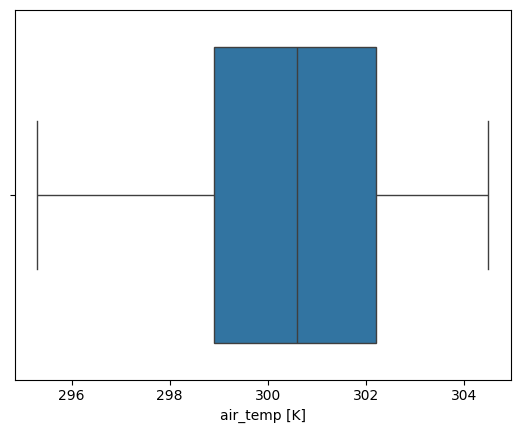

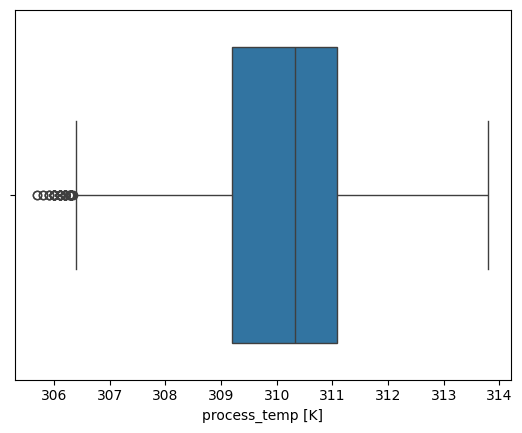

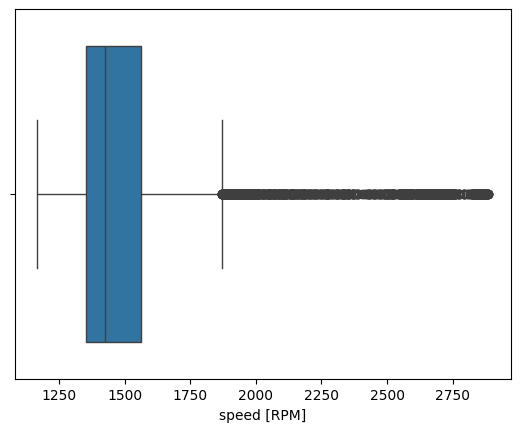

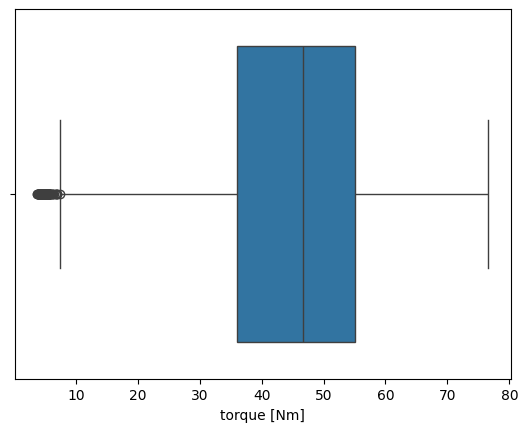

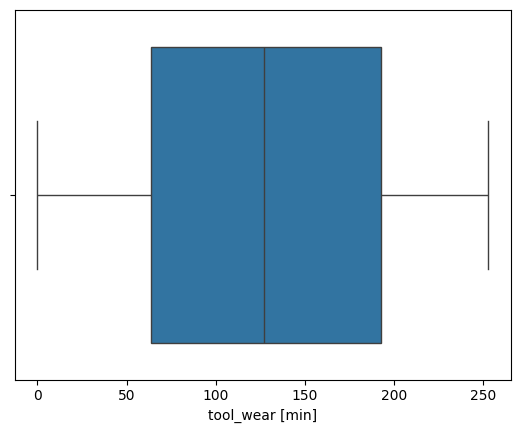

In [ ]:
# Visualizamos valores atipicos
# Boxplot individual 
import seaborn as sns

for col in cols:
    sns.boxplot(x=df[col])
    plt.show()

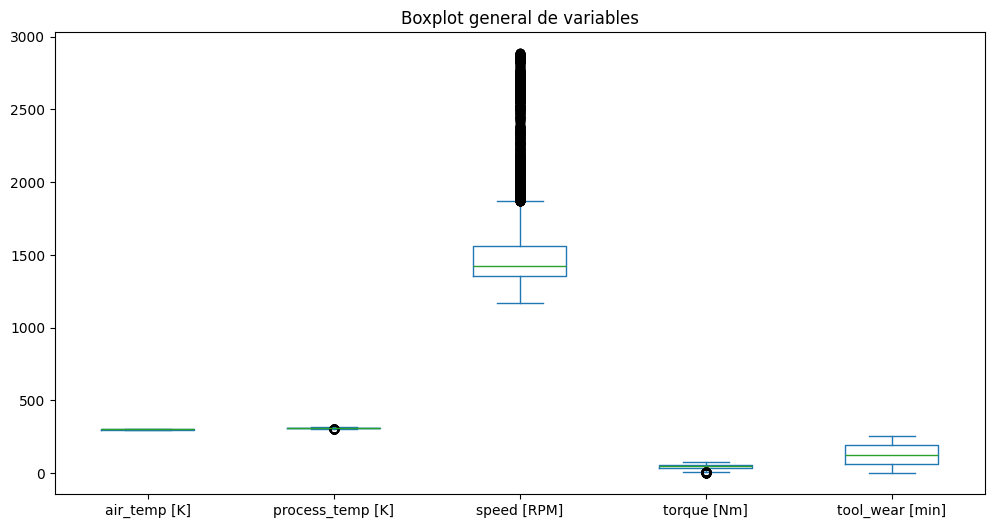

In [35]:
# Boxplot general 
cols = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']
df[cols].plot(kind='box', figsize=(12,6))
plt.title("Boxplot general de variables")
plt.show()

Se utilizaron boxplots tanto de forma general como individual para analizar la presencia de valores atípicos en las variables numéricas. Se observan valores atipicos en speed, torque y process_temp. 

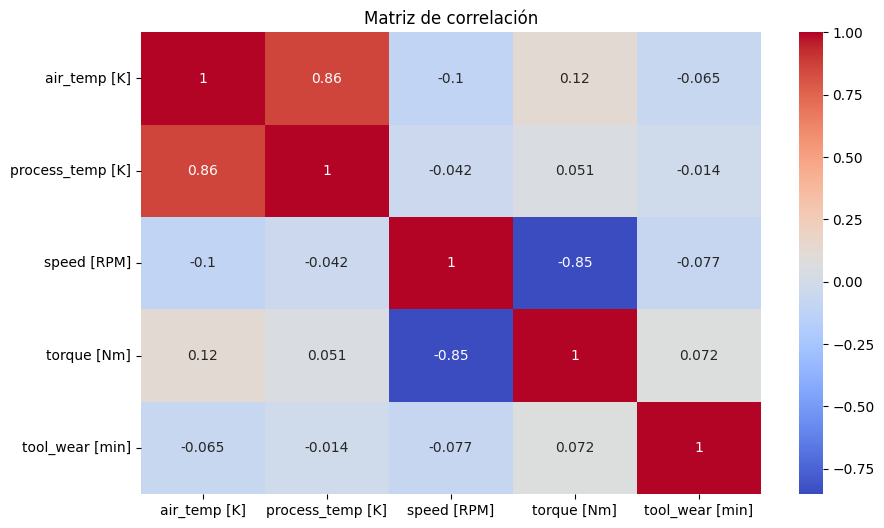

In [45]:
# Visualizamos la matriz de correlación de la columnas especificadas en cols
plt.figure(figsize=(10,6))

corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Matriz de correlación")
plt.show()

In [51]:
import pandas as pd

# Volver a cargar el dataset original
df = pd.read_csv("i40 (datos).csv")

# Codificar variables categóricas
df['product_type'] = df['product_type'].astype('category').cat.codes
df['target'] = df['target'].map({'normal': 0, 'failure': 1})

df.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
0,0,5291,1,303.80,313.30,1406,52.10,166,0
1,1,3908,1,302.30,311.20,1633,36.40,114,0
2,2,10767,2,302.27,311.47,1228,68.75,187,1
3,3,15484,1,302.35,311.93,1522,36.99,214,1
4,4,784,1,296.70,307.90,1743,27.90,55,0


In [59]:
# Balance del conjunto de datos
# Visualizamos la cantidad de registros por clase en la variable objetivo
# Esto nos permite identificar si el dataset está desbalanceado
df['target'].value_counts()

target
1    7482
0    7039
Name: count, dtype: int64

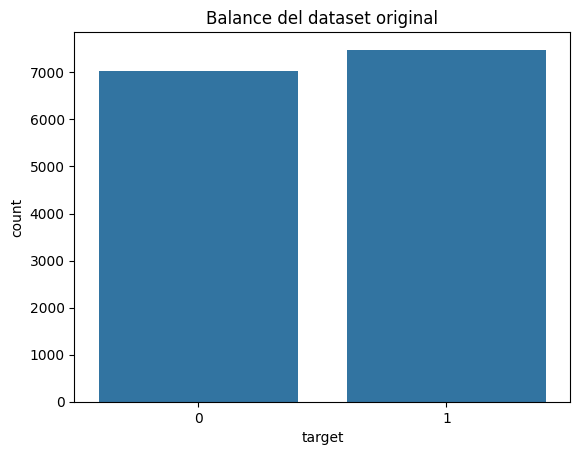

In [54]:
# Graficamos la distribución de la variable target
# Para ver visualmente si hay más casos de una clase que de otra
sns.countplot(x='target', data=df)
plt.title("Balance del dataset original")
plt.show()

In [53]:
# Separamos clases
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]

In [55]:
# Aumentamos la cantidad de registros de la clase minoritaria
# Tomamos muestras con reemplazo hasta igualar la cantidad de la clase mayoritaria
df_minority_upsampled = df_minority.sample(
    n=len(df_majority),   # igualamos cantidad de filas
    replace=True,         # permite repetir filas
    random_state=42       # asegura reproducibilidad
)

In [56]:
# Unimos la clase mayoritaria con la minoritaria ya balanceada
df_balanced = pd.concat([df_majority, df_minority_upsampled])

In [57]:
# Mezclamos las filas para evitar que queden ordenadas por clase
df_balanced = df_balanced.sample(frac=1, random_state=42)

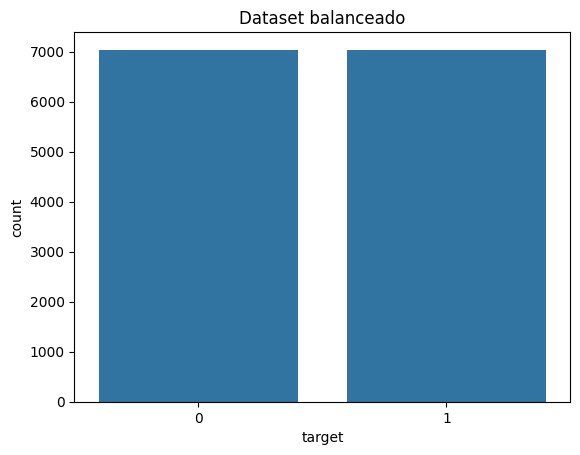

In [58]:
# Verificamos que ahora ambas clases tengan la misma cantidad
df_balanced['target'].value_counts()

# Visualizamos el nuevo balance con un gráfico
sns.countplot(x='target', data=df_balanced)
plt.title("Dataset balanceado")
plt.show()

In [60]:
# Normalización (Min-Max)

# Creamos una copia del dataset
df_normal = df_balanced.copy()

# Seleccionamos variables numéricas (sin target)
cols = ['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]']

# Aplicamos normalización Min-Max
for col in cols:
    df_normal[col] = (df_normal[col] - df_normal[col].min()) / (df_normal[col].max() - df_normal[col].min())

# Verificamos
df_normal.head()

,idx,parent_device_id,product_type,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],target
9609,9609,7962,1,0.619565,0.802469,0.475580,0.593407,0.234127,0
5565,5565,16956,0,0.736957,0.560494,0.444406,0.771154,0.575397,1
5760,5760,19283,0,0.547826,0.518519,0.483201,0.586951,0.833333,1
6729,6729,6937,0,0.576087,0.666667,0.503291,0.500000,0.111111,0
9138,9138,13648,0,0.784783,0.618519,0.442674,0.727610,0.095238,1


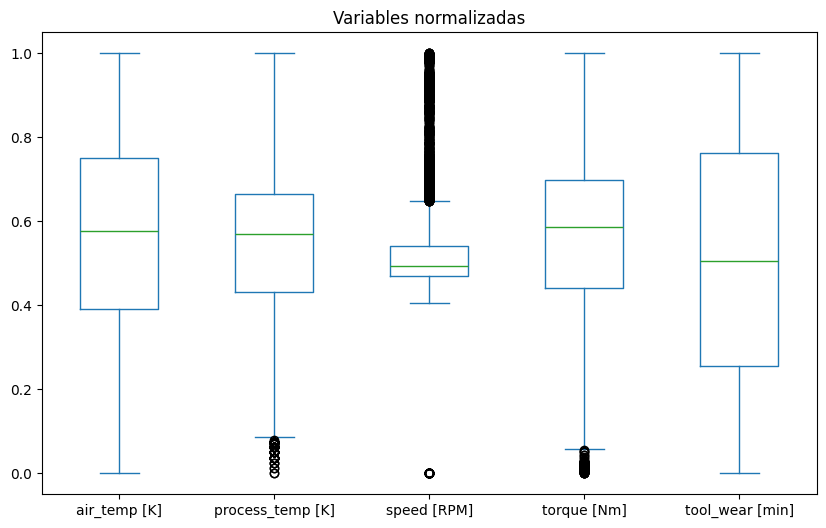

In [61]:
# Visualizamos
df_normal[cols].plot(kind='box', figsize=(10,6))
plt.title("Variables normalizadas")
plt.show()

In [62]:
# Preparación de datos para modelado

# Definimos las variables de entrada (X) y la variable objetivo (y)
X = df_normal.drop(columns=['target', 'idx', 'parent_device_id'])
y = df_normal['target']

# Verificamos dimensiones
print(X.shape)
print(y.shape)

(14078, 6)
(14078,)


In [63]:
from sklearn.model_selection import train_test_split

# Dividimos el dataset en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Mostramos tamaños
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

ModuleNotFoundError: No module named 'sklearn'